In [1]:
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)  
import seaborn as sns
import numpy as np

In [2]:
# waste datasets
pack_waste = pd.read_csv("./data/ten00063_page_linear_2_0.csv", sep=",")
mun_waste = pd.read_csv("./data/sdg_11_60_linear_2_0.csv", sep=",")
elect_waste = pd.read_csv("./data/cei_wm060_linear_2_0.csv", sep=",")
waste_per_cap = pd.read_csv("./data/env_wasmun_linear_2_0.csv", sep=",")
batterie_waste = pd.read_csv("./data/LeadBatterieLife.csv", sep=";")
vehicle_waste = pd.read_csv("./data/vehicleEndOfLife.csv", sep=";")

# country characteristics
gdp_per_cap = pd.read_csv("./data/gdp-per-capita-worldbank.csv", sep=",")
urban_pop = pd.read_csv("./data/share-of-population-urban.csv", sep=",")
waste_expenditure = pd.read_csv("./data/IMF_COFOG_GENM_GF0501_WIDEF.csv", sep=",")
pop_density = pd.read_csv("./data/tps00003_linear_2_0.csv", sep=",")
educ = pd.read_csv("./data/edat_lfs_9903__custom_19291848_linear_2_0.csv", sep=",")

# extra datsets
join_year = pd.read_csv("./data/eu_joining_year.csv", sep=";")
waste_policies = pd.read_csv("./data/EU_waste_policies.csv", sep=";")

## Transform long datasets

In [3]:
vehicle_waste_long = vehicle_waste.melt(
    id_vars=["Codes", "Labels"],      
    var_name="Year",                 
    value_name="Value"                
)
vehicle_waste_long["Year"] = vehicle_waste_long["Year"].astype(int)
vehicle_waste_long["Value"] = (
    vehicle_waste_long["Value"]
    .replace(":", pd.NA)        
    .str.replace(",", ".", regex=False)
)
vehicle_waste_long["Value"] = pd.to_numeric(vehicle_waste_long["Value"], errors="coerce")
vehicle_waste = vehicle_waste_long.sort_values(by=["Codes", "Year"]).reset_index(drop=True)

batterie_waste_long = batterie_waste.melt(
    id_vars=["Codes", "Labels"],      
    var_name="Year",                 
    value_name="Value"                
)
batterie_waste_long["Year"] = batterie_waste_long["Year"].astype(int)
batterie_waste_long["Value"] = (
    batterie_waste_long["Value"]
    .replace(":", pd.NA)        
    .str.replace(",", ".", regex=False)
)
batterie_waste_long["Value"] = pd.to_numeric(batterie_waste_long["Value"], errors="coerce")
batterie_waste = batterie_waste_long.sort_values(by=["Codes", "Year"]).reset_index(drop=True)


# Filter waste expenditure #
print(waste_expenditure.columns)
waste_expenditure = waste_expenditure[waste_expenditure["SECTOR"] == "IMF_SEC_GG"]
waste_expenditure = waste_expenditure[waste_expenditure["UNIT_MEASURE"] == "PT_GDP"]
cols_to_keep = (
    ['REF_AREA', 'REF_AREA_LABEL'] +
    [col for col in waste_expenditure.columns if col.isdigit()]
)
waste_expenditure = waste_expenditure[cols_to_keep]
print(waste_expenditure.columns)
waste_expenditure_long = waste_expenditure.melt(
    id_vars=["REF_AREA", "REF_AREA_LABEL"],     
    var_name="Year",                
    value_name="Value"                
)
waste_expenditure_long["Year"] = waste_expenditure_long["Year"].astype(int)
waste_expenditure_long["Value"] = pd.to_numeric(waste_expenditure_long["Value"], errors="coerce")
waste_expenditure = waste_expenditure_long.sort_values(by=["REF_AREA", "Year"]).reset_index(drop=True)

Index(['FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR',
       'INDICATOR_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'SECTOR',
       'SECTOR_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT',
       'UNIT_MULT_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF',
       'OBS_CONF_LABEL', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')
Index(['REF_AREA', 'REF_AREA_LABEL', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       '2022', '2023'],
      dtype='object')


## Filter to only include EU countries

In [4]:
eu_countries_map = {
    'EU27_2020': 'European Union - 27 countries (from 2020)',
    'AT': 'Austria',
    'BE': 'Belgium',
    'BG': 'Bulgaria',
    'HR': 'Croatia',
    'CY': 'Cyprus',
    'CZ': 'Czechia',
    'DK': 'Denmark',
    'EE': 'Estonia',
    'FI': 'Finland',
    'FR': 'France',
    'DE': 'Germany',
    'EL': 'Greece',
    'HU': 'Hungary',
    'IE': 'Ireland',
    'IT': 'Italy',
    'LV': 'Latvia',
    'LT': 'Lithuania',
    'LU': 'Luxembourg',
    'MT': 'Malta',
    'NL': 'Netherlands',
    'PL': 'Poland',
    'PT': 'Portugal',
    'RO': 'Romania',
    'SK': 'Slovakia',
    'SI': 'Slovenia',
    'ES': 'Spain',
    'SE': 'Sweden'
}

eu_countries_map_iso3 = {
    'EU27_2020': 'European Union - 27 countries (from 2020)',
    'AUT': 'Austria',
    'BEL': 'Belgium',
    'BGR': 'Bulgaria',
    'HRV': 'Croatia',
    'CYP': 'Cyprus',
    'CZE': 'Czechia',
    'DNK': 'Denmark',
    'EST': 'Estonia',
    'FIN': 'Finland',
    'FRA': 'France',
    'DEU': 'Germany',
    'GRC': 'Greece',
    'HUN': 'Hungary',
    'IRL': 'Ireland',
    'ITA': 'Italy',
    'LVA': 'Latvia',
    'LTU': 'Lithuania',
    'LUX': 'Luxembourg',
    'MLT': 'Malta',
    'NLD': 'Netherlands',
    'POL': 'Poland',
    'PRT': 'Portugal',
    'ROU': 'Romania',
    'SVK': 'Slovakia',
    'SVN': 'Slovenia',
    'ESP': 'Spain',
    'SWE': 'Sweden'
}


def filter_to_eu27(df, geo_col, name="Dataset", iso3 = False):
    """
    Filters the dataframe to keep only the 27 current EU member states AND the EU27_2020 aggregate.
    Prints statistics and explicitly lists the countries/codes that were removed.
    """
    if iso3:
        c_map = eu_countries_map_iso3
    else:
        c_map = eu_countries_map

    initial_rows = len(df)
    
    # 1. Identify what is currently in the dataframe
    current_geo = set(df[geo_col].dropna().unique())
    
    # 2. Identify valid keys (EU countries + EU Aggregate)
    valid_geo = set(c_map.keys())
    
    # 3. Calculate the difference (What will be removed?)
    removed_geo = current_geo - valid_geo
    
    # 4. Filter: Keep rows where geo_col is in our valid keys
    df_filtered = df[df[geo_col].isin(valid_geo)].copy()
    
    removed_rows = initial_rows - len(df_filtered)
    
    print(f"[{name}] Filtered to EU-27 + Aggregate:")
    print(f"   - Kept: {len(df_filtered)} rows")
    print(f"   - Removed: {removed_rows} rows")
    
    if removed_geo:
        
        print(f"   - Removed Countries/Aggregates: {sorted(list(removed_geo))}")
    else:
        print(f"   - No countries removed (Dataset matched requirements exactly).")
    
    print("-" * 40) 
    
    return df_filtered


In [5]:
# Filter educ #
educ = educ[educ["isced11"] == "ED5-8"]

In [6]:
# 1. Packaging Waste
pack_waste = filter_to_eu27(pack_waste, 'geo', "Packaging Waste")

# 2. Municipal Waste
mun_waste = filter_to_eu27(mun_waste, 'geo', "Municipal Waste")

# 3. E-Waste
elect_waste = filter_to_eu27(elect_waste, 'geo', "E-Waste")

# 4. Waste Per Capita
waste_per_cap = filter_to_eu27(waste_per_cap, 'geo', "Waste Per Capita")

# 5. Batterie waste
batterie_waste = filter_to_eu27(batterie_waste, 'Codes', "Batterie Waste")

# 6. Vecile waste
vehicle_waste = filter_to_eu27(vehicle_waste, 'Codes', "Vecile waste")

# 7. GDP per Capita
gdp_per_cap = filter_to_eu27(gdp_per_cap, 'Code', "GDP Per Capita", iso3 = True)

# 8. Urban population
urban_pop = filter_to_eu27(urban_pop, 'Code', "Urban population", iso3 = True)

# 9. Waste expenditure
waste_expenditure = filter_to_eu27(waste_expenditure, 'REF_AREA', "Waste expenditure", iso3 = True)

# 11. Population density
pop_density = filter_to_eu27(pop_density, 'geo', "Population density")

# 11. Education
educ = filter_to_eu27(educ, 'geo', "Education")

print("\nAll datasets restricted to EU-27 countries.")

[Packaging Waste] Filtered to EU-27 + Aggregate:
   - Kept: 329 rows
   - Removed: 36 rows
   - Removed Countries/Aggregates: ['IS', 'LI', 'NO']
----------------------------------------
[Municipal Waste] Filtered to EU-27 + Aggregate:
   - Kept: 658 rows
   - Removed: 120 rows
   - Removed Countries/Aggregates: ['AL', 'BA', 'CH', 'IS', 'ME', 'MK', 'NO', 'RS', 'TR', 'XK']
----------------------------------------
[E-Waste] Filtered to EU-27 + Aggregate:
   - Kept: 470 rows
   - Removed: 46 rows
   - Removed Countries/Aggregates: ['IS', 'LI', 'NO']
----------------------------------------
[Waste Per Capita] Filtered to EU-27 + Aggregate:
   - Kept: 14349 rows
   - Removed: 3104 rows
   - Removed Countries/Aggregates: ['AL', 'BA', 'CH', 'IS', 'ME', 'MK', 'NO', 'RS', 'TR', 'XK']
----------------------------------------
[Batterie Waste] Filtered to EU-27 + Aggregate:
   - Kept: 405 rows
   - Removed: 45 rows
   - Removed Countries/Aggregates: ['IS', 'NO', 'UKN']
-----------------------------

## Join all datastes

In [7]:
alpha3_to_alpha2 = {
    "AUT": "AT",
    "BEL": "BE",
    "BGR": "BG",
    "HRV": "HR",
    "CYP": "CY",
    "CZE": "CZ",
    "DNK": "DK",
    "EST": "EE",
    "FIN": "FI",
    "FRA": "FR",
    "DEU": "DE",
    "GRC": "EL",  # Greece is 'EL' in Eurostat
    "HUN": "HU",
    "IRL": "IE",
    "ITA": "IT",
    "LVA": "LV",
    "LTU": "LT",
    "LUX": "LU",
    "MLT": "MT",
    "NLD": "NL",
    "POL": "PL",
    "PRT": "PT",
    "ROU": "RO",
    "SVK": "SK",
    "SVN": "SI",
    "ESP": "ES",
    "SWE": "SE",
    "EU27_2020": "EU27_2020"  # keep EU aggregate as is
}

def to_alpha2(code):
    """Convert 3-letter country code to 2-letter for EU countries; otherwise keep as is."""
    return alpha3_to_alpha2.get(code, code)


pack_waste_fin = pack_waste[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
mun_waste_fin = mun_waste[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
elect_waste_fin = elect_waste[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
waste_per_cap_fin = waste_per_cap[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
batterie_waste_fin = batterie_waste[["Codes", "Year", "Value"]].rename(
    columns={"Codes": "country","Year": "year","Value": "value"}
)
vehicle_waste_fin = vehicle_waste[["Codes", "Year", "Value"]].rename(
    columns={"Codes": "country","Year": "year","Value": "value"}
)
waste_expenditure_fin = waste_expenditure[["REF_AREA", "Year", "Value"]].rename(
    columns={"REF_AREA": "country","Year": "year","Value": "value"}
)
gdp_per_cap_fin = gdp_per_cap[["Code", "Year", "GDP per capita, PPP (constant 2021 international $)"]].rename(
    columns={"Code": "country","Year": "year","GDP per capita, PPP (constant 2021 international $)": "value"}
)
urban_pop_fin = urban_pop[["Code", "Year", "Urban population (% of total population)"]].rename(
    columns={"Code": "country","Year": "year","Urban population (% of total population)": "value"}
)
pop_density_fin = pop_density[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
educ_fin = educ[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
join_year = join_year.rename(
    columns={"geo": "country","joining_year": "joining_year"}
)

display(educ_fin)


,country,year,value
2393,AT,2004,15.8
2394,AT,2005,15.0
2395,AT,2006,14.7
2396,AT,2007,14.6
2397,AT,2008,15.0
...,...,...,...
3104,SK,2020,23.9
3105,SK,2021,24.7
3106,SK,2022,26.0
3107,SK,2023,25.8


In [8]:
from functools import reduce
pack_waste_fin      = pack_waste_fin.rename(columns={"value": "packaging_recycling"})
mun_waste_fin       = mun_waste_fin.rename(columns={"value": "municipal_recycling"})
elect_waste_fin     = elect_waste_fin.rename(columns={"value": "electrical_recycling"})
waste_per_cap_fin   = waste_per_cap_fin.rename(columns={"value": "waste_per_capita"})
batterie_waste_fin  = batterie_waste_fin.rename(columns={"value": "battery_recycling"})
vehicle_waste_fin   = vehicle_waste_fin.rename(columns={"value": "vehicle_recycling"})
waste_expenditure_fin   = waste_expenditure_fin.rename(columns={"value": "waste_expenditure"})
gdp_per_cap_fin     = gdp_per_cap_fin.rename(columns={"value": "gdp_per_capita"})
urban_pop_fin       = urban_pop_fin.rename(columns={"value": "urban_population_share"})
pop_density_fin     = pop_density_fin.rename(columns={"value": "population_density"})
educ_fin            = educ_fin.rename(columns={"value": "education_attainment"})
dfs = [pack_waste_fin, mun_waste_fin, elect_waste_fin,
      batterie_waste_fin, vehicle_waste_fin, gdp_per_cap_fin, urban_pop_fin, pop_density_fin, educ_fin, waste_expenditure_fin]  
#i = 1
for df in dfs:
    df["country"] = df["country"].apply(to_alpha2)
    #print(i)
    #print(df["country"].nunique())
    #i = i+1

df_merged = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["country", "year"],
        how="outer"
    ),
    dfs
)
df_merged = df_merged[
    (df_merged["year"] >= 2000) &
    (df_merged["year"] <= 2023)
].sort_values(["country", "year"]).reset_index(drop=True)

df_merged = df_merged.merge(
    join_year,           
    on="country",           
    how="left"              
)
df_merged["joining_year"] = pd.to_numeric(df_merged["joining_year"], errors="coerce")
df_merged["joining_year"] = df_merged["joining_year"].astype(float).astype('Int64')
# Source - https://stackoverflow.com/a
# Posted by Abhishek Bhatia
# Retrieved 2025-12-29, License - CC BY-SA 4.0

df_merged.to_csv("./data/merged_dataset.csv", index=False)

In [ ]:
duplicates = (
    df_merged
    .groupby(["country", "year"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
)

if duplicates.empty:
    print("✅ Jede (country, year)-Kombination kommt genau einmal vor.")
else:
    print("❌ Es gibt doppelte (country, year)-Kombinationen:")
    display(duplicates)


# Number of countries #
print(df_merged["country"].nunique())


✅ Jede (country, year)-Kombination kommt genau einmal vor.
28


In [10]:
#print(waste_policies.columns)
df_merged_all = df_merged.copy()

for abbr in waste_policies["abbreviation"].unique():
    df_merged_all[abbr] = 0
#df_merged_all


In [11]:

for abbr in waste_policies["abbreviation"].unique(): 
    df_merged_all[abbr] = 0 
    for abbr, pol_group in waste_policies.groupby("abbreviation"): 
        for _, pol in pol_group.iterrows(): 
            year_adopted = pol["year_adopted"] 
            if pol["eu_wide"] == "yes": 
                mask = df_merged_all["year"] >= year_adopted 
            else: 
                mask = ( (df_merged_all["country"] == pol["country"]) & (df_merged_all["year"] >= year_adopted) ) 
            df_merged_all.loc[mask, abbr] = 1

In [12]:
df_merged_all.to_csv("./data/merged_dataset_all.csv", index=False)

## Analyzing missing values 


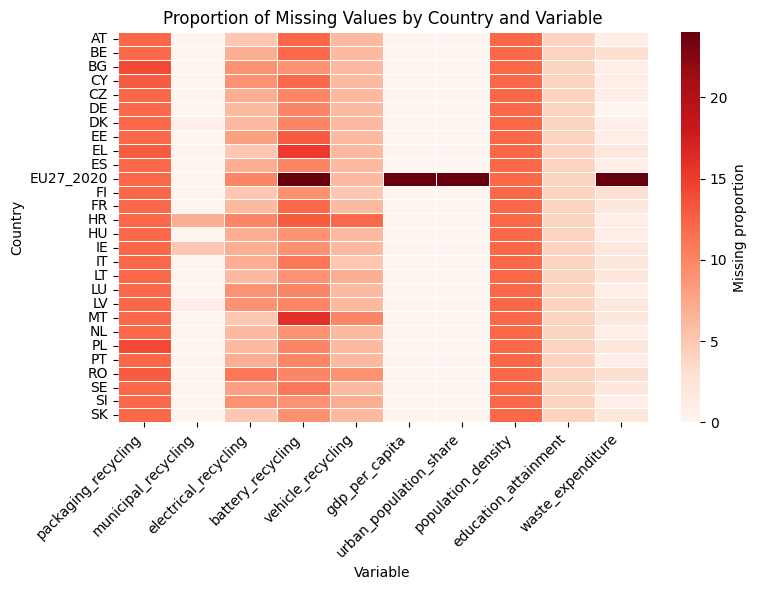

In [13]:
missing_by_country = (
    df_merged
    .groupby("country")
    .apply(lambda x: x.isna().sum())
)
missing_by_country = missing_by_country.drop(["country", "year", "joining_year"], axis = 1)
missing_by_country

plt.figure(figsize=(8, 6))
sns.heatmap(
    missing_by_country,
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Missing proportion"}
)

plt.title("Proportion of Missing Values by Country and Variable")
plt.xlabel("Variable")
plt.ylabel("Country")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


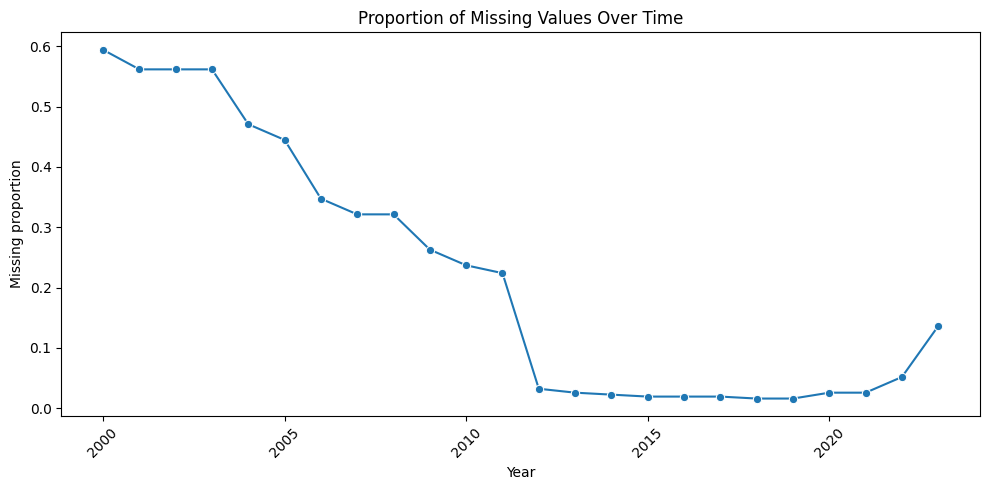

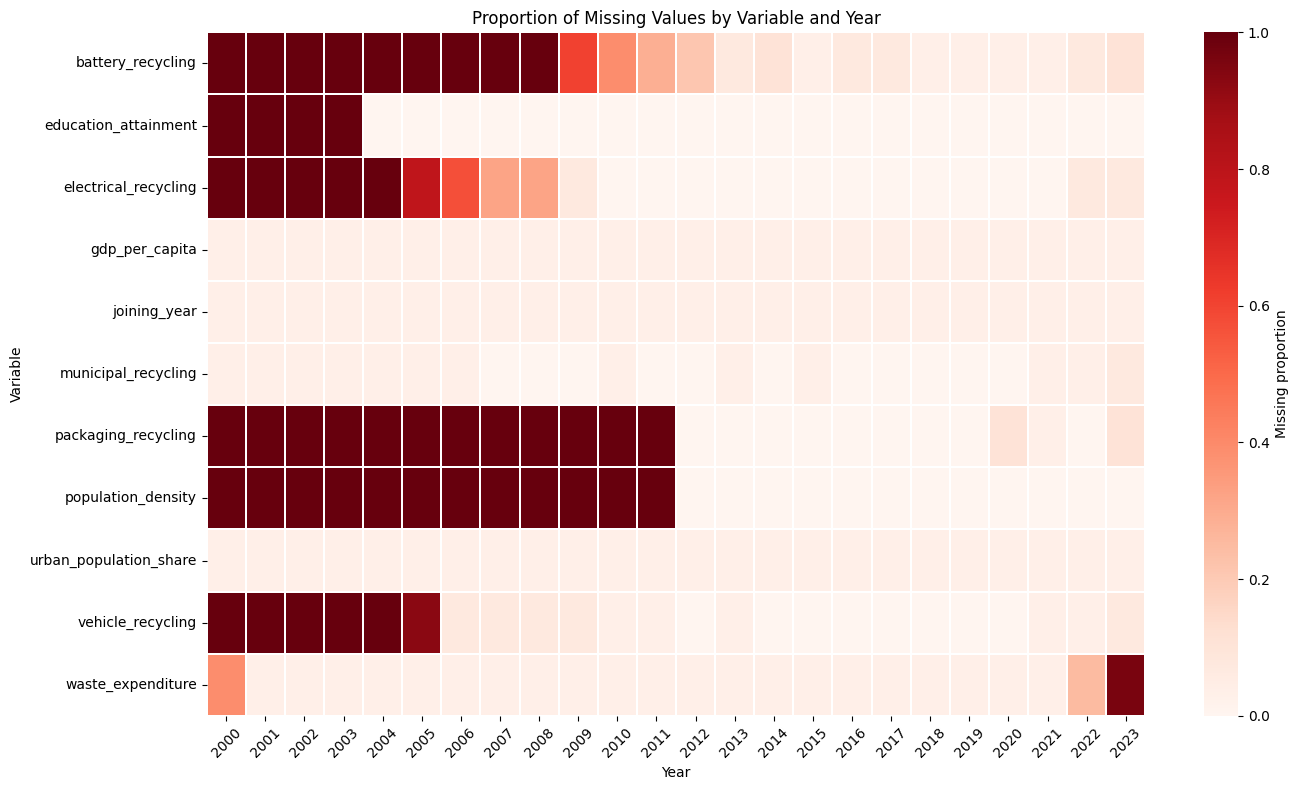

In [14]:
df_long = df_merged.melt(
    id_vars=["country", "year"],
    var_name="variable",
    value_name="value"
)
missing_by_year = (
    df_long
    .groupby("year")["value"]
    .apply(lambda x: x.isna().mean())
    .reset_index(name="missing")
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=missing_by_year,
    x="year",
    y="missing",
    marker="o"
)

plt.title("Proportion of Missing Values Over Time")
plt.xlabel("Year")
plt.ylabel("Missing proportion")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


missing_var_year = (
    df_long
    .groupby(["variable", "year"])["value"]
    .apply(lambda x: x.isna().mean())
    .reset_index(name="missing")
)
heatmap_var_year = missing_var_year.pivot(
    index="variable",
    columns="year",
    values="missing"
)
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_var_year,
    cmap="Reds",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Missing proportion"}
)

plt.title("Proportion of Missing Values by Variable and Year")
plt.xlabel("Year")
plt.ylabel("Variable")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




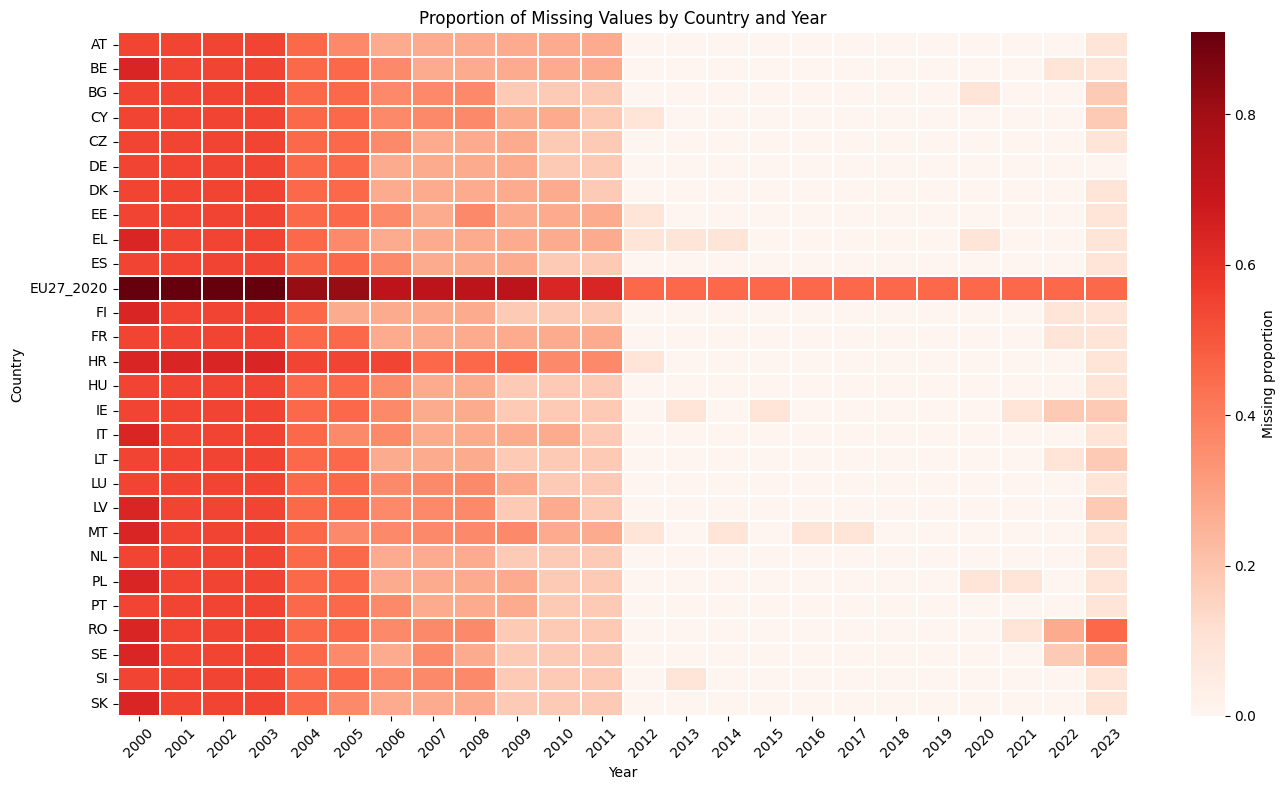

In [15]:
missing_country_year = (
    df_long
    .groupby(["country", "year"])["value"]
    .apply(lambda x: x.isna().mean())
    .reset_index(name="missing")
)

heatmap_country_year = missing_country_year.pivot(
    index="country",
    columns="year",
    values="missing"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_country_year,
    cmap="Reds",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Missing proportion"}
)

plt.title("Proportion of Missing Values by Country and Year")
plt.xlabel("Year")
plt.ylabel("Country")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [16]:
df_merged['waste_expenditure'] = df_merged['waste_expenditure']*100
df_merged_all['waste_expenditure'] = df_merged_all['waste_expenditure']*100

In [17]:
df_merged

,country,year,packaging_recycling,municipal_recycling,electrical_recycling,battery_recycling,vehicle_recycling,gdp_per_capita,urban_population_share,population_density,education_attainment,waste_expenditure,joining_year
0,AT,2000,NaN,63.4,NaN,NaN,NaN,53599.610,60.213,NaN,NaN,5.562567,1995
1,AT,2001,NaN,64.3,NaN,NaN,NaN,54098.027,59.934,NaN,NaN,5.696860,1995
2,AT,2002,NaN,62.5,NaN,NaN,NaN,54631.600,59.655,NaN,NaN,5.821767,1995
3,AT,2003,NaN,64.2,NaN,NaN,NaN,54986.742,59.375,NaN,NaN,5.681384,1995
4,AT,2004,NaN,57.4,NaN,NaN,NaN,56048.480,59.094,NaN,15.8,5.112889,1995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,SK,2019,67.5,38.5,91.2,91.2,95.5,37194.137,53.729,112.0,23.1,34.564973,2004
668,SK,2020,70.8,45.3,92.6,91.3,95.6,36201.414,53.760,112.0,23.9,46.338775,2004
669,SK,2021,73.9,48.9,92.5,90.8,95.6,38346.094,53.820,112.1,24.7,36.495568,2004
670,SK,2022,71.8,49.5,90.9,91.2,95.9,38623.670,53.909,111.5,26.0,37.664891,2004


## Analyzing outliers

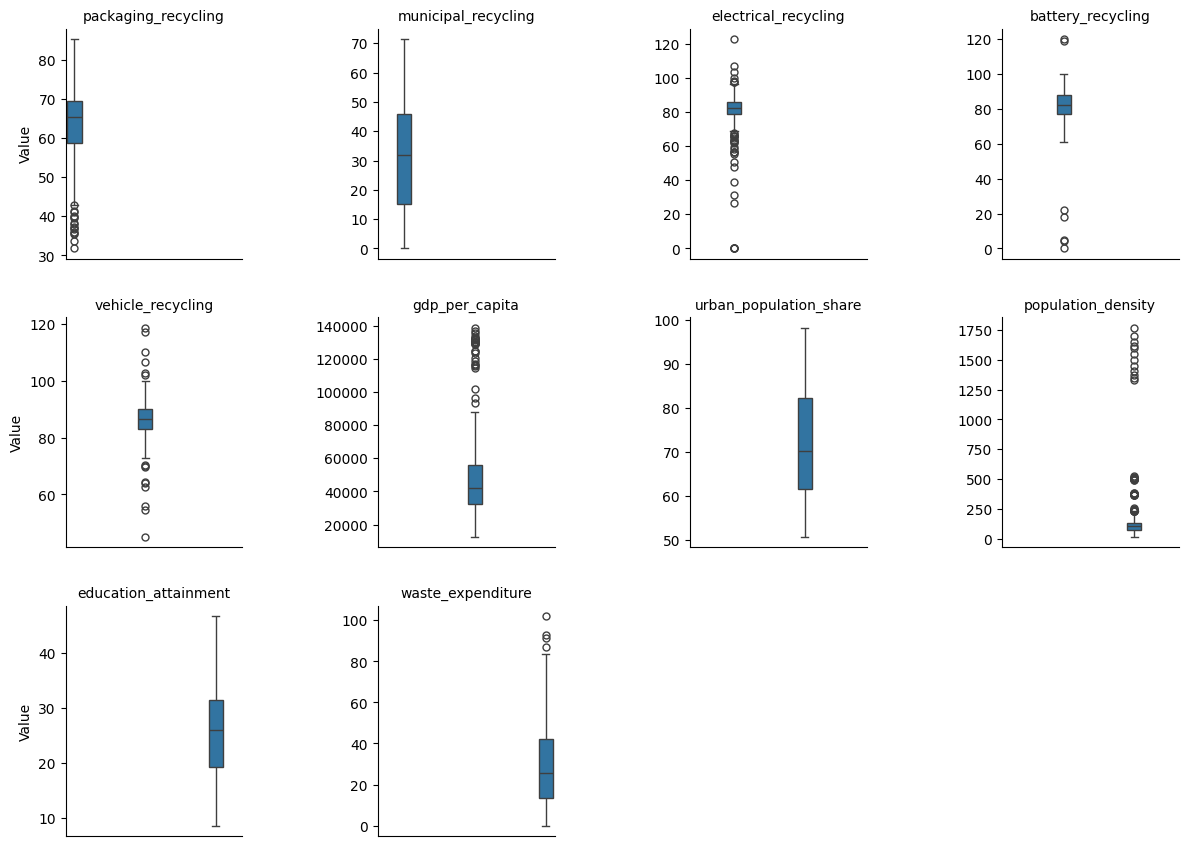

In [18]:
numeric_vars = (
    df_merged
    .select_dtypes(include=[np.number])
    .drop(["year", "joining_year"], axis = 1)
)
numeric_vars

df_long = df_merged.melt(
    value_vars=numeric_vars,
    var_name="variable",
    value_name="value"
)

g = sns.catplot(
    data=df_long,
    x="variable",
    y="value",
    kind="box",
    col="variable",
    col_wrap=4,
    sharey=False,
    height=3
)

g.set_titles("{col_name}")
g.set_axis_labels("", "Value")

# REMOVE x-axis
for ax in g.axes.flat:
    ax.set_xticks([])
    ax.set_xlabel("")

# g = sns.catplot(
#     data=df_long,
#     x="variable",
#     y="value",
#     kind="box",
#     col="variable",
#     col_wrap=4,
#     sharey=False,
#     height=3
# )

# g.set_titles("{col_name}")
# g.set_axis_labels("", "Value")

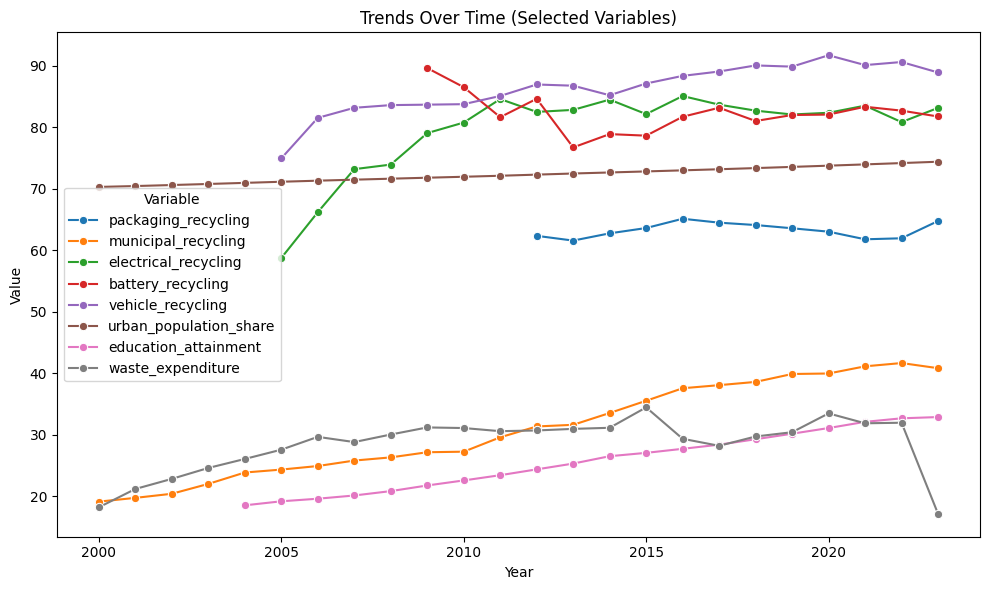

In [19]:
selected_vars = [
    "packaging_recycling", "municipal_recycling", "electrical_recycling", "battery_recycling", "vehicle_recycling", 
    "urban_population_share", "education_attainment", "waste_expenditure"
]
df_year = (
    df_merged
    .groupby("year")[selected_vars]
    .mean()
    .reset_index()
)
df_year_long = df_year.melt(
    id_vars="year",
    var_name="variable",
    value_name="value"
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_year_long,
    x="year",
    y="value",
    hue="variable",
    marker="o"
)

plt.title("Trends Over Time (Selected Variables)")
plt.xlabel("Year")
plt.ylabel("Value")

plt.legend(title="Variable")
plt.tight_layout()
plt.show()



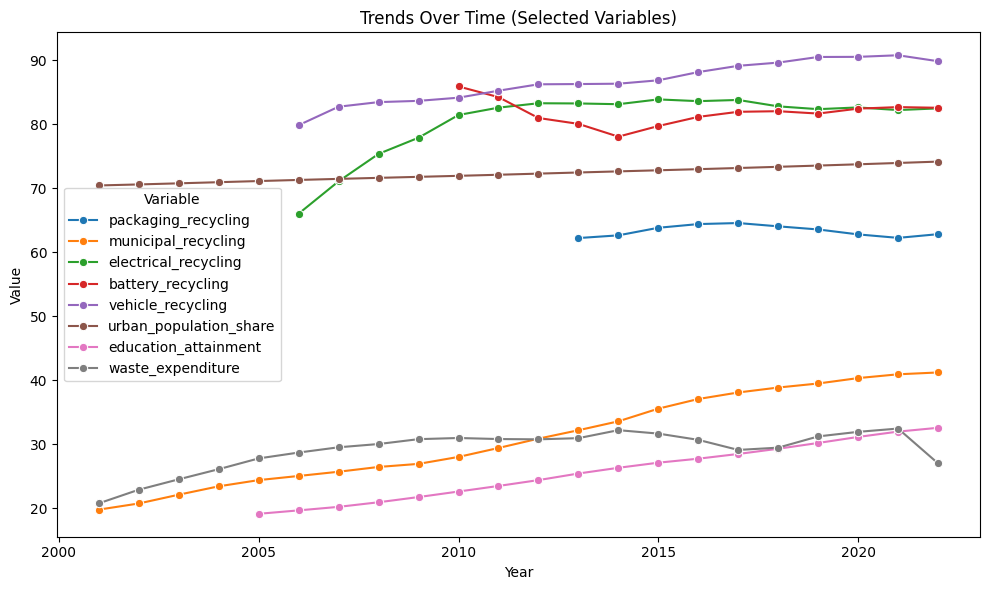

In [20]:
df_year[selected_vars] = (
    df_year[selected_vars]
    .rolling(window=3, center=True)
    .mean()
)
df_year_long = df_year.melt(
    id_vars="year",
    var_name="variable",
    value_name="value"
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_year_long,
    x="year",
    y="value",
    hue="variable",
    marker="o"
)

plt.title("Trends Over Time (Selected Variables)")
plt.xlabel("Year")
plt.ylabel("Value")

plt.legend(title="Variable")
plt.tight_layout()
plt.show()


In [21]:
df_year_long = df_year.melt(
    id_vars="year",        # the column to keep fixed
    value_vars=selected_vars,  # columns to melt
    var_name="variable",
    value_name="value"
)



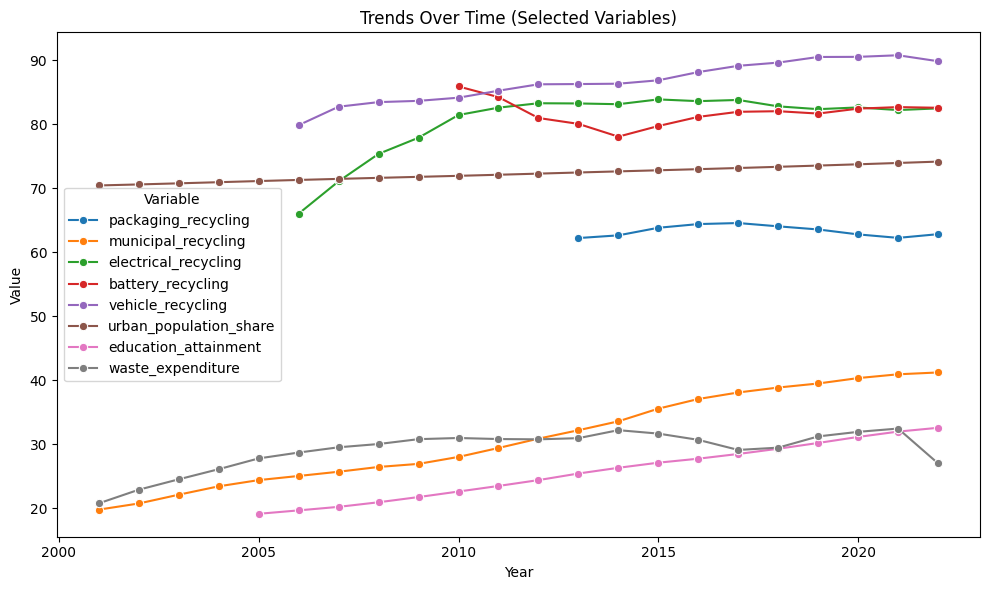

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_year_long,
    x="year",
    y="value",
    hue="variable",
    marker="o"
)

plt.title("Trends Over Time (Selected Variables)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend(title="Variable")
plt.tight_layout()
plt.show()


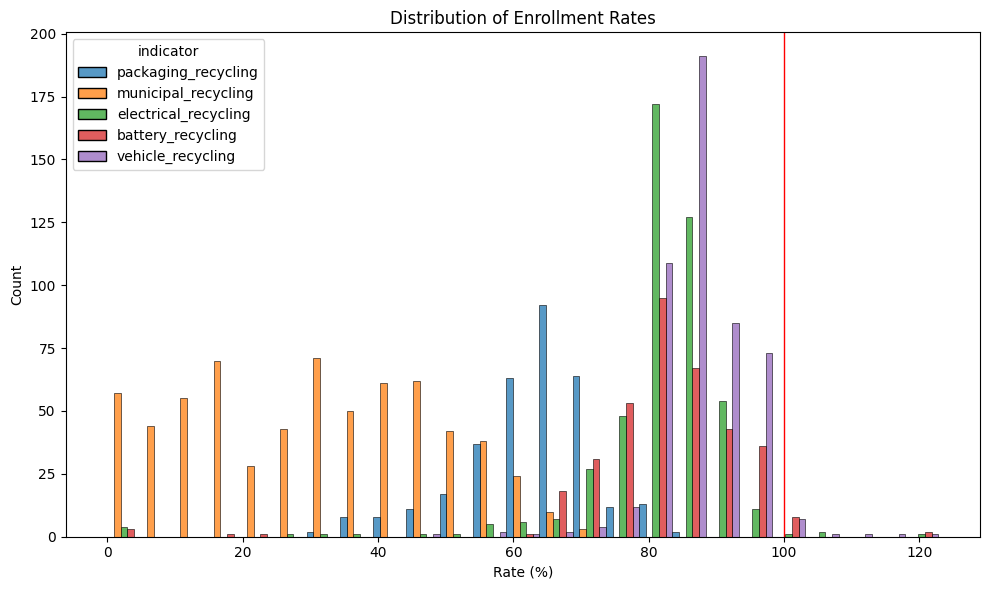

In [23]:
rate_indicators = ["packaging_recycling", "municipal_recycling", "electrical_recycling", "battery_recycling", "vehicle_recycling"]
#rate_indicators = [
#    "packaging_recycling", "municipal_recycling", "electrical_recycling", "battery_recycling", "vehicle_recycling", 
#    "urban_population_share", "education_attainment", "waste_expenditure"
#]

rates_long = df_merged.melt(
    id_vars=[],                 # no id columns in your R example
    value_vars=rate_indicators, # columns to melt
    var_name="indicator",
    value_name="value"
)
rates_long["indicator"] = rates_long["indicator"].astype(str)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=rates_long,
    x="value",
    hue="indicator",
    multiple="dodge",
    binwidth=5,
    edgecolor="black",
    legend=True  # ensure legend is requested
)

# Vertical line at 100
plt.axvline(x=100, color="red", linewidth=1, linestyle="solid")

plt.title("Distribution of Enrollment Rates")
plt.xlabel("Rate (%)")
plt.ylabel("Count")


plt.tight_layout()
plt.show()

#colors = ["green", "red", "violet", "skyblue", "orange"]


## Correlation-Analysis

                        packaging_recycling  municipal_recycling  \
packaging_recycling                1.000000             0.635275   
municipal_recycling                0.635275             1.000000   
electrical_recycling               0.004799             0.179969   
battery_recycling                  0.037165             0.079286   
vehicle_recycling                  0.167166             0.224674   
urban_population_share             0.205430             0.361476   
education_attainment               0.311167             0.472820   
waste_expenditure                 -0.136388            -0.128881   

                        electrical_recycling  battery_recycling  \
packaging_recycling                 0.004799           0.037165   
municipal_recycling                 0.179969           0.079286   
electrical_recycling                1.000000           0.035691   
battery_recycling                   0.035691           1.000000   
vehicle_recycling                   0.190995        

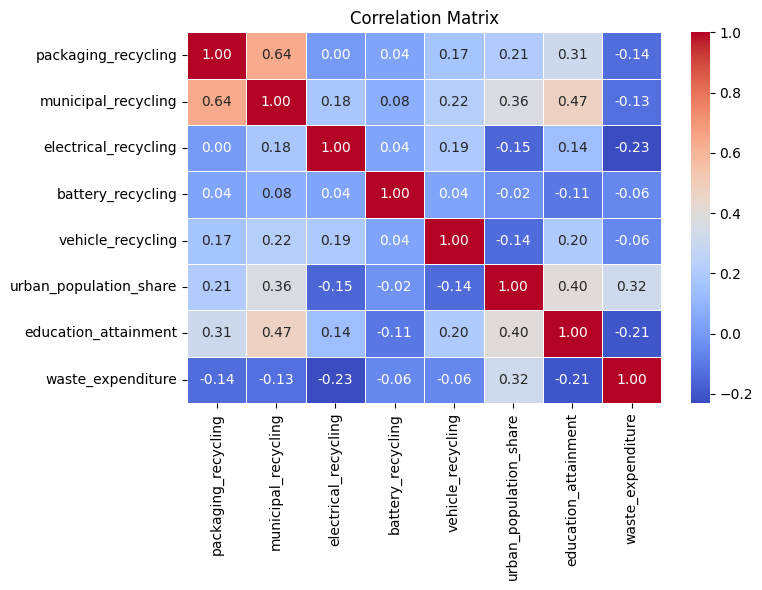

In [24]:

corr = df_merged[selected_vars].corr()
print(corr)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



## Regression

Index(['year', 'municipal_recycling', 'gdp_per_capita',
       'urban_population_share', 'population_density', 'education_attainment',
       'waste_expenditure', 'joining_year', 'policy_count'],
      dtype='object')


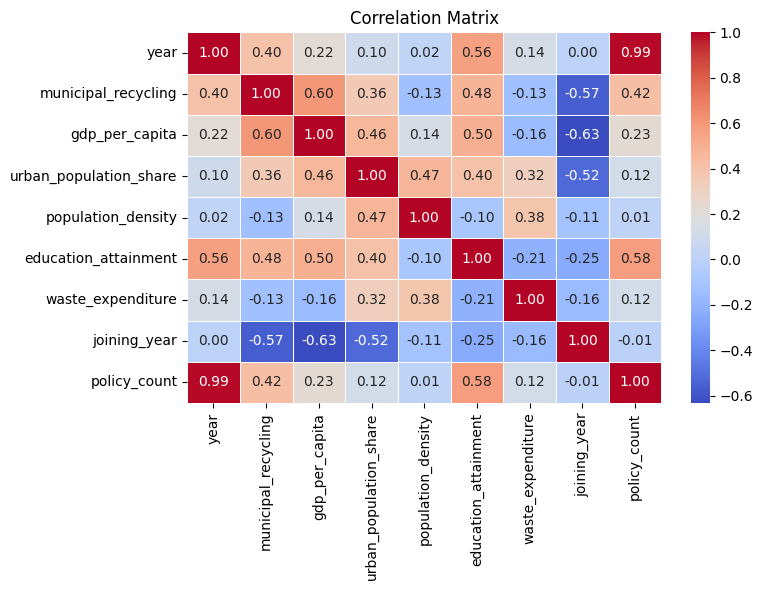

In [25]:
df = df_merged_all.copy()
policy_years_cols = ['WFD', 'WEEE_Directive_1', 'WEEE_Directive_2', 'WEEE_Directive_3', 'WEEE_Directive_4', 'RoHS_1', 'RoHS_2', 
                    'BL', 'EOLVD', 'LFD_1', 'LFD_2', 'SUP', 'CEAP_1', 'CEAP_2', 'CEAP_3', 'DRS', 'PT']
df["policy_count"] = (df[policy_years_cols] > 0).sum(axis=1)
df = df.drop(policy_years_cols, axis = 1)

df = df[df['country'] != "EU27_2020"]
df['joining_year'] = df['joining_year'].astype('int64')
df = df.drop(['country', 'packaging_recycling', 'electrical_recycling', 'battery_recycling', 'vehicle_recycling'],axis = 1)
print(df.columns)

corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



In [26]:
train = df[df['year'] <= 2016].copy()
test  = df[df['year'] > 2016].copy()

In [27]:
import statsmodels.api as sm
X_train = train.drop("municipal_recycling", axis = 1)
y_train = train['municipal_recycling']

In [28]:
X_train = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train, missing='drop')
results = model.fit()
print(results.summary())


                             OLS Regression Results                            
Dep. Variable:     municipal_recycling   R-squared:                       0.646
Model:                             OLS   Adj. R-squared:                  0.624
Method:                  Least Squares   F-statistic:                     28.34
Date:                 Wed, 31 Dec 2025   Prob (F-statistic):           1.23e-24
Time:                         00:04:54   Log-Likelihood:                -479.76
No. Observations:                  133   AIC:                             977.5
Df Residuals:                      124   BIC:                             1004.
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const             

In [29]:
print(X_train.dtypes)
print(y_train.dtype)




const                     float64
year                        int64
gdp_per_capita            float64
urban_population_share    float64
population_density        float64
education_attainment      float64
waste_expenditure         float64
joining_year                int64
policy_count                int64
dtype: object
float64
